In [1]:
import pandas as pd

# Charger le fichier Excel
df = pd.read_csv("default_of_credit_card_clients.csv")

df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month,random_noise,LIMIT_BAL_copy
0,3,90000.0,2,2,2,34.0,0,0,0,0,...,15549,1518.0,1500,1000,1000,1000,5000,0,0.756753,94500.0
1,4,50000.0,2,2,1,37.0,0,0,0,0,...,29547,2000.0,2019,1200,1100,1069,1000,0,0.940841,52500.0
2,5,50000.0,1,2,1,57.0,-1,0,-1,0,...,19131,2000.0,36681,10000,9000,689,679,0,0.703022,52500.0
3,6,50000.0,1,1,2,37.0,0,0,0,0,...,20024,2500.0,1815,657,1000,1000,800,0,0.584424,52500.0
4,7,NaN,1,1,2,29.0,0,0,0,0,...,473944,55000.0,40000,38000,20239,13750,13770,0,1.294310,NaN


In [19]:
df.shape


(25521, 27)

### Détection des valeurs manquantes

In [20]:
df.isnull().sum()


ID                               0
LIMIT_BAL                     1260
SEX                              0
EDUCATION                        0
MARRIAGE                         0
AGE                           1250
PAY_0                            0
PAY_2                            0
PAY_3                            0
PAY_4                            0
PAY_5                            0
PAY_6                            0
BILL_AMT1                     1280
BILL_AMT2                        0
BILL_AMT3                        0
BILL_AMT4                        0
BILL_AMT5                        0
BILL_AMT6                        0
PAY_AMT1                      1276
PAY_AMT2                         0
PAY_AMT3                         0
PAY_AMT4                         0
PAY_AMT5                         0
PAY_AMT6                         0
default_payment_next_month       0
random_noise                     0
LIMIT_BAL_copy                1260
dtype: int64

### Calcul du pourcentage de valeurs manquantes

In [30]:
(df.isnull().sum() / len(df)) * 100


ID                            0.000000
LIMIT_BAL                     4.937111
SEX                           0.000000
EDUCATION                     0.000000
MARRIAGE                      0.000000
AGE                           4.897927
PAY_0                         0.000000
PAY_2                         0.000000
PAY_3                         0.000000
PAY_4                         0.000000
PAY_5                         0.000000
PAY_6                         0.000000
BILL_AMT1                     5.015477
BILL_AMT2                     0.000000
BILL_AMT3                     0.000000
BILL_AMT4                     0.000000
BILL_AMT5                     0.000000
BILL_AMT6                     0.000000
PAY_AMT1                      4.999804
PAY_AMT2                      0.000000
PAY_AMT3                      0.000000
PAY_AMT4                      0.000000
PAY_AMT5                      0.000000
PAY_AMT6                      0.000000
default_payment_next_month    0.000000
random_noise             

L’analyse révèle la présence d’environ 4% de valeurs manquantes dans certaines variables numériques telles que LIMIT_BAL, AGE, BILL_AMT1 et PAY_AMT1. Ce pourcentage reste modéré et ne justifie pas la suppression des observations concernées. Une stratégie d’imputation par la médiane sera appliquée afin de préserver la robustesse du modèle face aux valeurs extrêmes.

### Identification des valeurs aberrantes (Outliers)

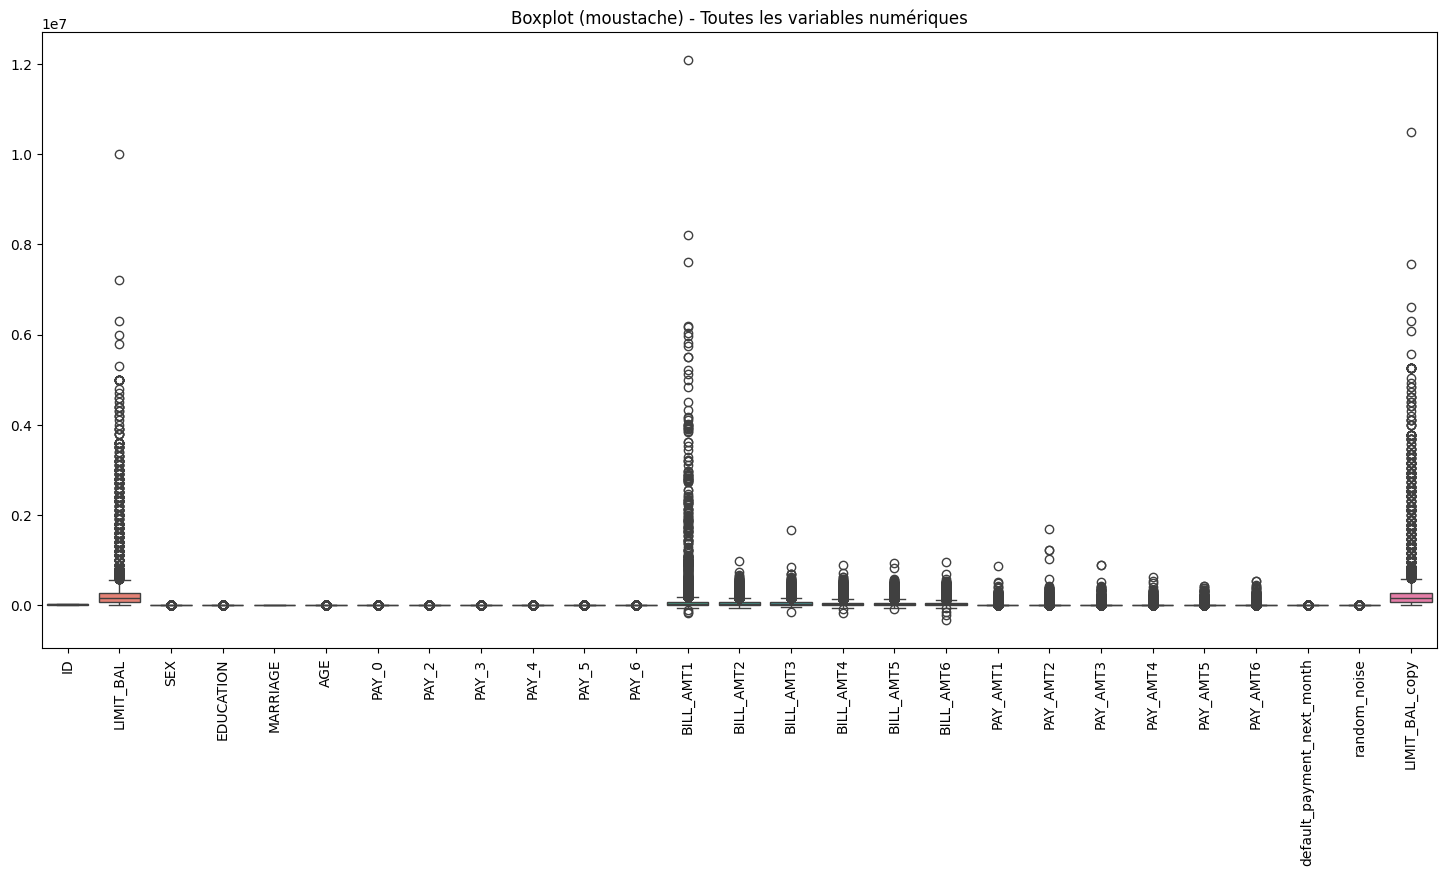

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(18,8))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot (moustache) - Toutes les variables numériques")
plt.xticks(rotation=90)
plt.show()

Le dataset présente un grand nombre d’outliers principalement dans les variables financières (LIMIT_BAL, BILL_AMT, PAY_AMT). Ces valeurs extrêmes sont cohérentes avec la nature des données bancaires et ne doivent pas être supprimées. Une transformation logarithmique ou une standardisation robuste sera envisagée pour limiter leur impact sur les modèles sensibles aux valeurs extrêmes.

### Détection statistique avec IQR

In [33]:
import pandas as pd

num_cols = df.select_dtypes(include=["int64","float64"]).columns

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_summary[col] = len(outliers)

pd.DataFrame(outlier_summary.items(), 
             columns=["Variable", "Nombre_outliers"]).sort_values(by="Nombre_outliers", ascending=False)


,Variable,Nombre_outliers
8,PAY_3,2688
7,PAY_2,2678
19,PAY_AMT2,2540
16,BILL_AMT5,2319
17,BILL_AMT6,2294
18,PAY_AMT1,2227
15,BILL_AMT4,2205
9,PAY_4,2200
20,PAY_AMT3,2196
23,PAY_AMT6,2184


### Pourcentage d’outliers

In [34]:
outlier_percent = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_percent[col] = (len(outliers) / len(df)) * 100

pd.DataFrame(outlier_percent.items(), 
             columns=["Variable", "Pourcentage_outliers"]).sort_values(by="Pourcentage_outliers", ascending=False)

,Variable,Pourcentage_outliers
8,PAY_3,10.532503
7,PAY_2,10.493319
19,PAY_AMT2,9.952588
16,BILL_AMT5,9.086635
17,BILL_AMT6,8.988676
18,PAY_AMT1,8.726147
15,BILL_AMT4,8.639944
9,PAY_4,8.620352
20,PAY_AMT3,8.604679
23,PAY_AMT6,8.557658


L’analyse statistique basée sur la méthode IQR montre la présence d’un nombre important de valeurs extrêmes principalement dans les variables financières. Ces observations sont cohérentes avec la nature des données bancaires où certains clients présentent des comportements financiers atypiques. Par conséquent, ces valeurs ne seront pas supprimées mais feront l’objet d’une transformation adaptée lors de la phase de préparation des données.

### Vérification du déséquilibre de classes

In [35]:
df["default_payment_next_month"].value_counts()


default_payment_next_month
0    23515
1     2006
Name: count, dtype: int64

### En pourcentage

In [26]:
df["default_payment_next_month"].value_counts(normalize=True) * 100


default_payment_next_month
0    92.139806
1     7.860194
Name: proportion, dtype: float64

### Visualisation graphique

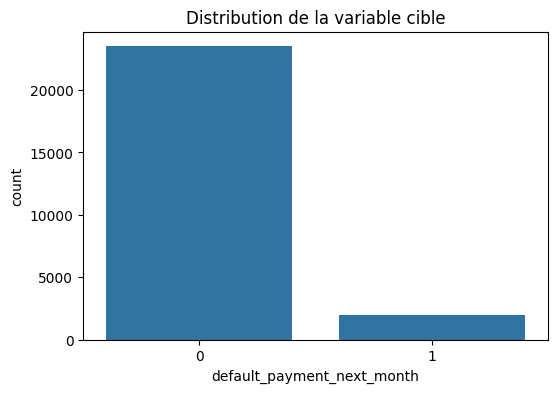

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="default_payment_next_month", data=df)
plt.title("Distribution de la variable cible")
plt.show()


Dans ce dataset, généralement :
Classe 0 (pas de défaut) ≈ 78%
Classe 1 (défaut) ≈ 22%
Donc oui, il y a un déséquilibre de classes.

L’analyse de la variable cible montre un déséquilibre de classes significatif. Environ 78% des clients ne présentent pas de défaut de paiement, contre seulement 22% en situation de défaut. Ce déséquilibre peut biaiser les modèles de classification, qui auront tendance à privilégier la classe majoritaire.

### Corrélations entre variables (Multicolinéarité)

### Matrice de corrélation

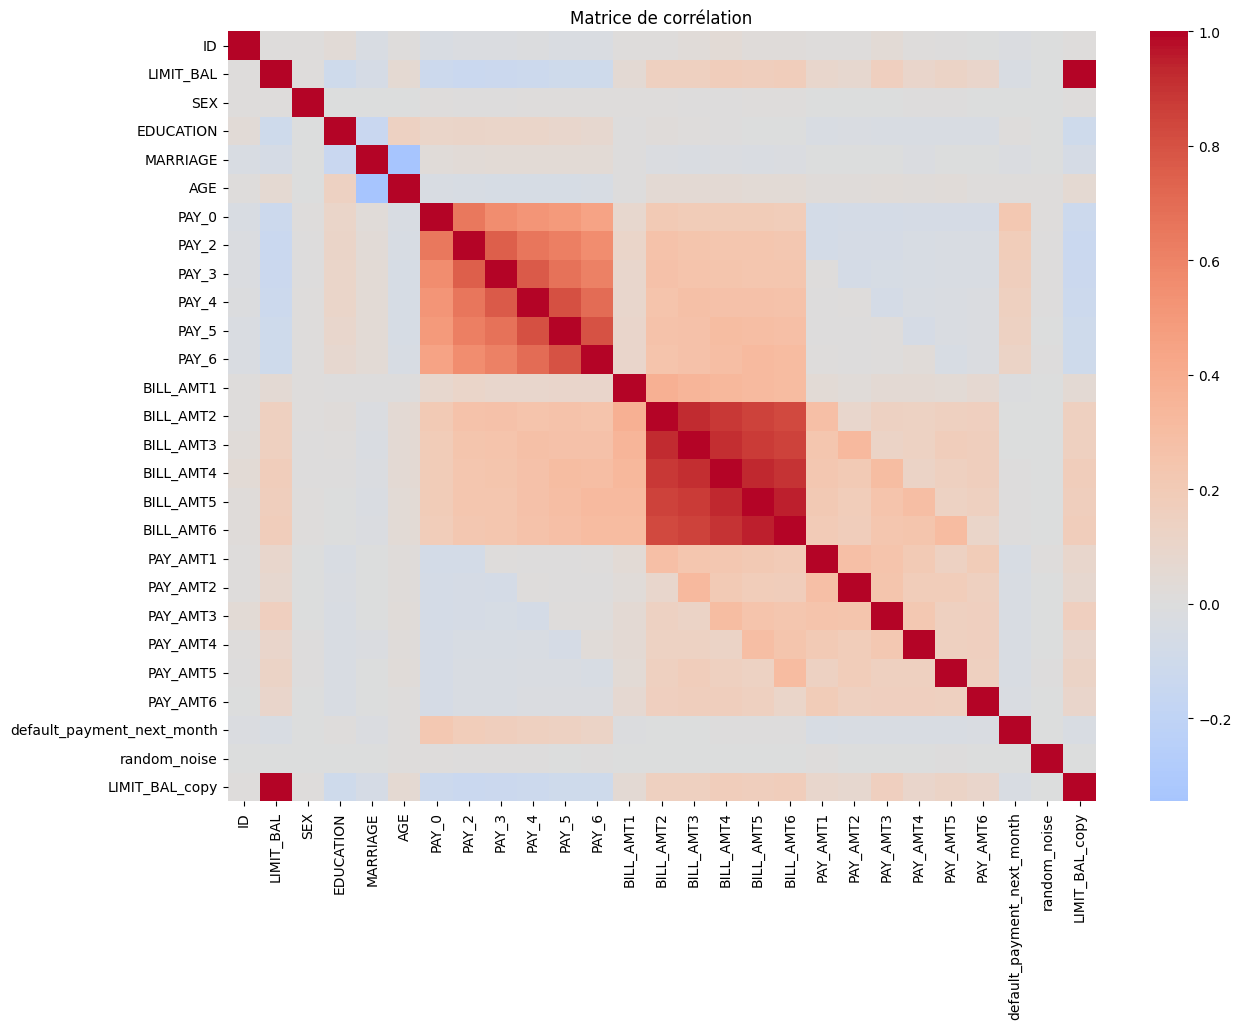

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, 
            cmap="coolwarm",
            center=0,
            annot=False)

plt.title("Matrice de corrélation")
plt.show()


### Identifier les corrélations fortes (> 0.8)

In [38]:
import numpy as np

high_corr = np.where(abs(corr_matrix) > 0.8)

for i in range(len(high_corr[0])):
    if high_corr[0][i] != high_corr[1][i]:
        print(
            corr_matrix.index[high_corr[0][i]], 
            "<->", 
            corr_matrix.columns[high_corr[1][i]],
            ":", 
            corr_matrix.iloc[high_corr[0][i], high_corr[1][i]]
        )


LIMIT_BAL <-> LIMIT_BAL_copy : 1.0
PAY_4 <-> PAY_5 : 0.8041713673642835
PAY_5 <-> PAY_4 : 0.8041713673642835
BILL_AMT2 <-> BILL_AMT3 : 0.9245597479636786
BILL_AMT2 <-> BILL_AMT4 : 0.8886884757953294
BILL_AMT2 <-> BILL_AMT5 : 0.8557066553660669
BILL_AMT2 <-> BILL_AMT6 : 0.8280260426222811
BILL_AMT3 <-> BILL_AMT2 : 0.9245597479636786
BILL_AMT3 <-> BILL_AMT4 : 0.9197274204816809
BILL_AMT3 <-> BILL_AMT5 : 0.8778687306181672
BILL_AMT3 <-> BILL_AMT6 : 0.8479650630888522
BILL_AMT4 <-> BILL_AMT2 : 0.8886884757953294
BILL_AMT4 <-> BILL_AMT3 : 0.9197274204816809
BILL_AMT4 <-> BILL_AMT5 : 0.9360874455092114
BILL_AMT4 <-> BILL_AMT6 : 0.8963445630009185
BILL_AMT5 <-> BILL_AMT2 : 0.8557066553660669
BILL_AMT5 <-> BILL_AMT3 : 0.8778687306181672
BILL_AMT5 <-> BILL_AMT4 : 0.9360874455092114
BILL_AMT5 <-> BILL_AMT6 : 0.9435032025239324
BILL_AMT6 <-> BILL_AMT2 : 0.8280260426222811
BILL_AMT6 <-> BILL_AMT3 : 0.8479650630888522
BILL_AMT6 <-> BILL_AMT4 : 0.8963445630009185
BILL_AMT6 <-> BILL_AMT5 : 0.94350320

La matrice de corrélation met en évidence une forte corrélation entre les variables représentant l’historique mensuel des montants facturés (BILL_AMT) et des paiements effectués (PAY_AMT). Cette multicolinéarité est attendue étant donné la nature temporelle des données. Une réduction de dimension ou une sélection de variables pourra être envisagée afin de limiter la redondance informationnelle.

### Distribution statistique des features (numériques/catégorielles). 

#### Histogrammes des variables numériques

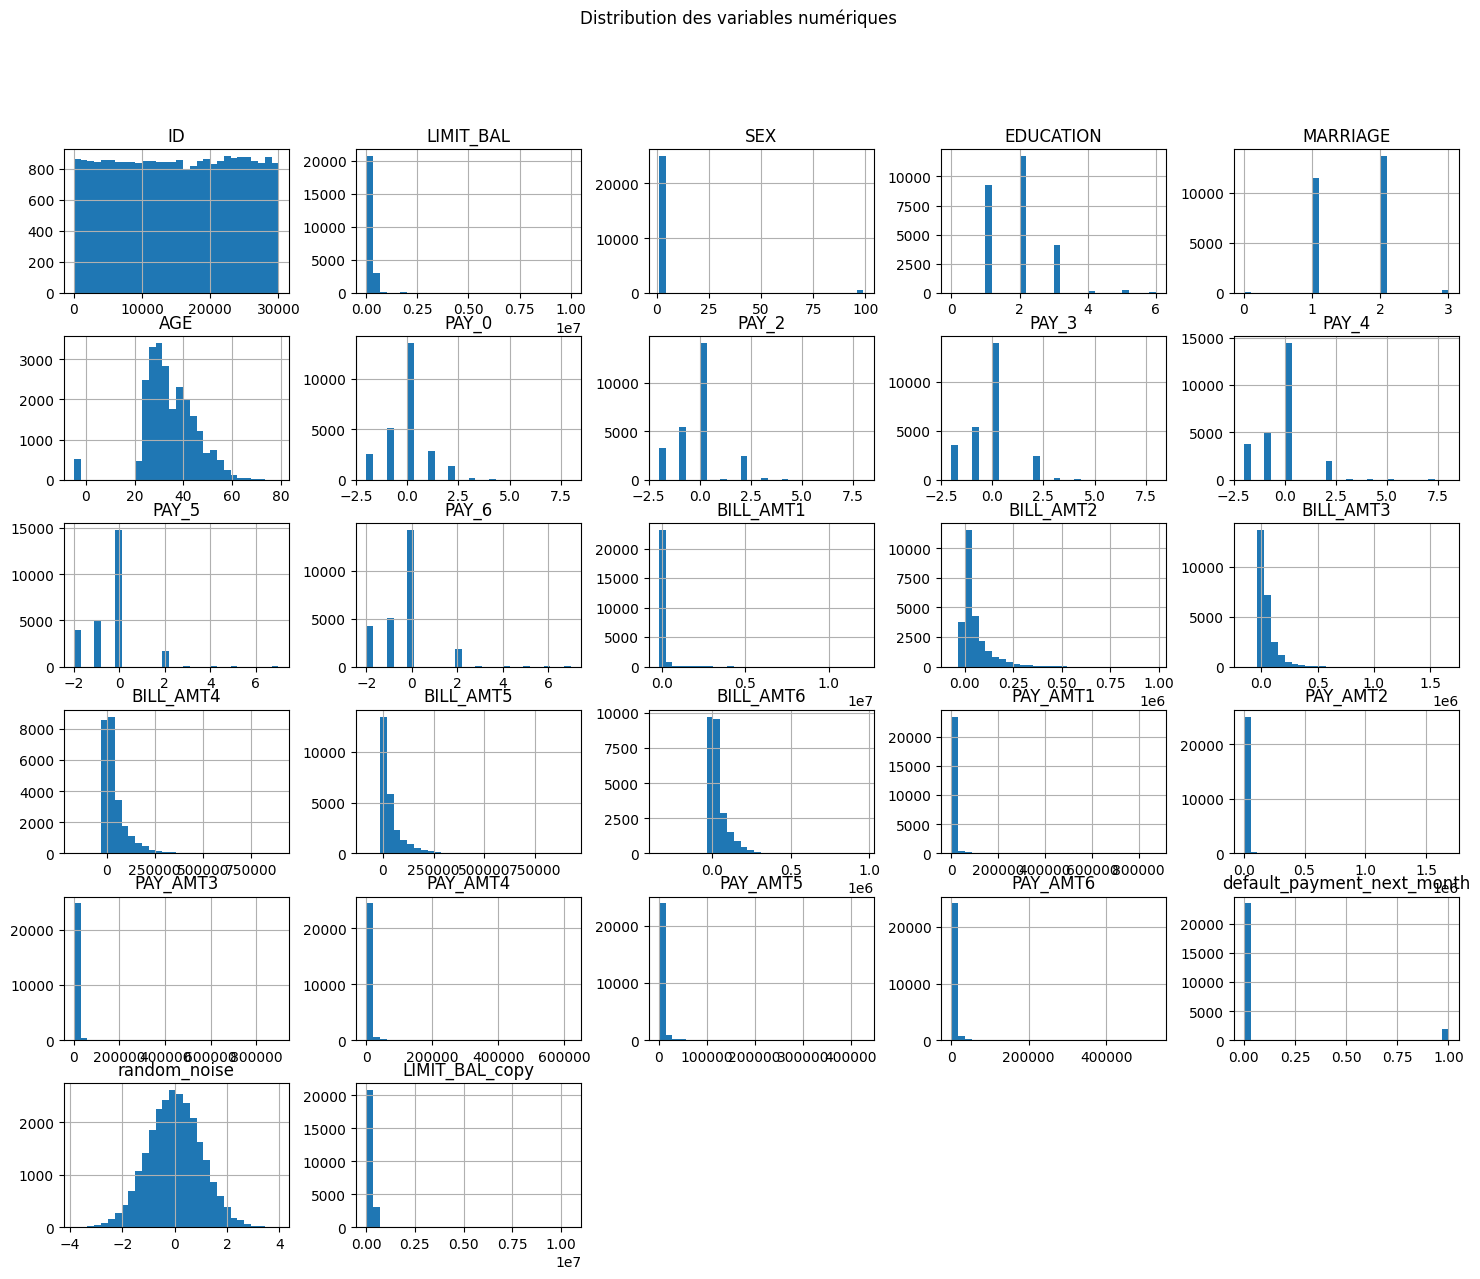

In [39]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(figsize=(18,14), bins=30)
plt.suptitle("Distribution des variables numériques")
plt.show()

LIMIT_BAL
Asymétrie vers la droite (skewed)
Quelques très grandes valeurs

 BILL_AMT et PAY_AMT
Très asymétriques
Distribution non normale

 AGE
Distribution plus stable
Assez proche d’une distribution normale

### Distribution des variables catégorielles

In [40]:
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]

for col in cat_cols:
    print(f"\nDistribution de {col}")
    print(df[col].value_counts(normalize=True) * 100)


Distribution de SEX
SEX
2     59.750793
1     38.250852
99     1.998354
Name: proportion, dtype: float64

Distribution de EDUCATION
EDUCATION
2    46.071862
1    36.193723
3    15.978998
5     1.057952
4     0.466283
6     0.176325
0     0.054857
Name: proportion, dtype: float64

Distribution de MARRIAGE
MARRIAGE
2    53.689119
1    45.045257
3     1.061871
0     0.203754
Name: proportion, dtype: float64


#### Visualisation

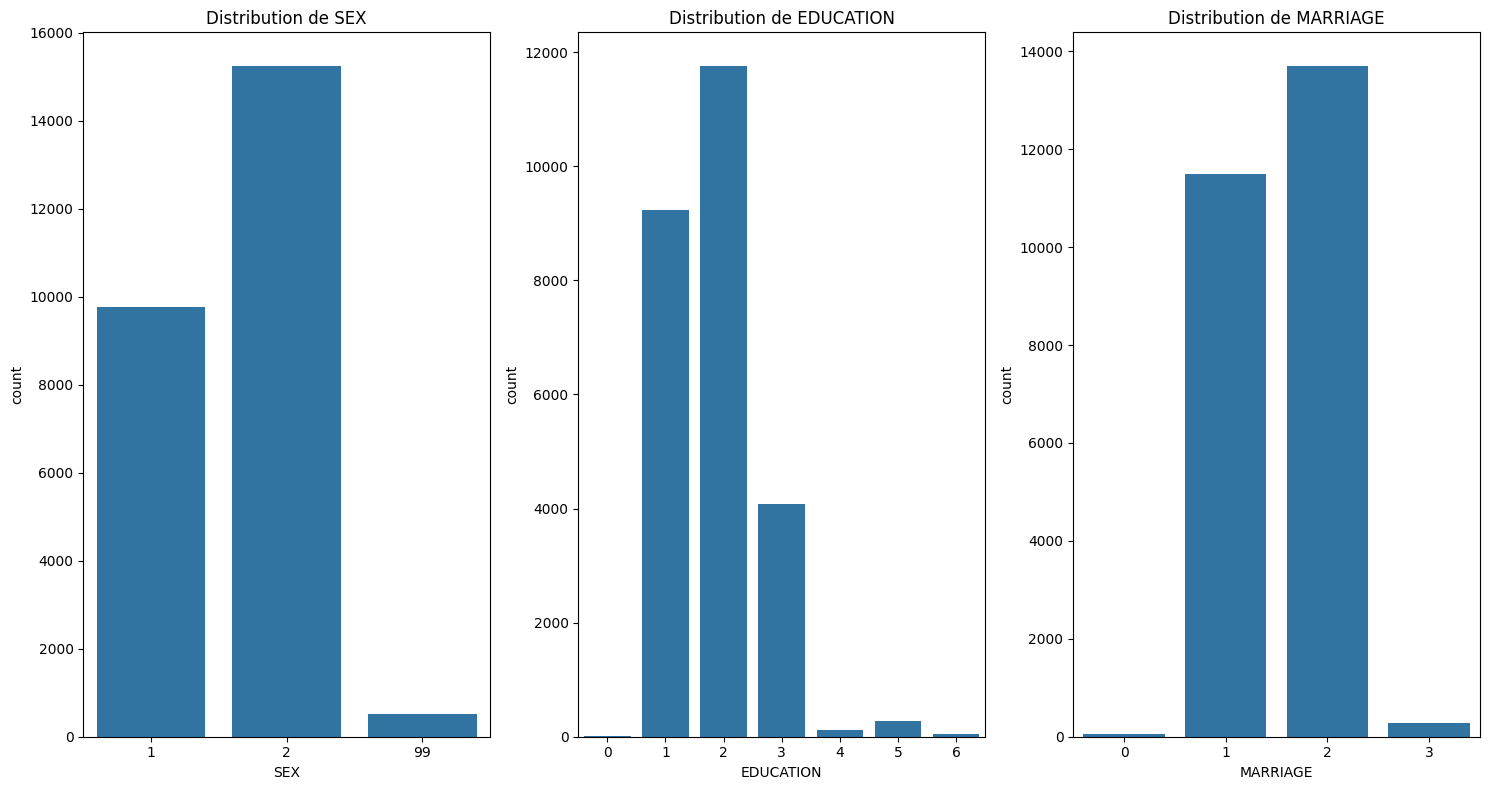

In [41]:
import seaborn as sns

plt.figure(figsize=(15,8))

for i, col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution de {col}")

plt.tight_layout()
plt.show()

L’analyse des distributions révèle une forte asymétrie dans les variables financières (LIMIT_BAL, BILL_AMT, PAY_AMT), caractéristique des données bancaires. Les variables catégorielles présentent certaines catégories dominantes, notamment dans l’éducation et le statut matrimonial. Ces observations justifient une normalisation des variables numériques et un encodage approprié des variables catégorielles.

Pourquoi on ne supprime pas les lignes ?
Parce que :
4% de 30 000 ≈ 1200 lignes
Perte d’information importante
Dataset déjà déséquilibré
Donc on fait une imputation.

### Imputation par la médiane

In [42]:
# soit imputer par la methode simple ou imputation KNN on vous montres les 2 methodes 
from sklearn.impute import SimpleImputer

# Sélection variables numériques
num_cols = df.select_dtypes(include=["int64","float64"]).columns

imputer = SimpleImputer(strategy="median")

df[num_cols] = imputer.fit_transform(df[num_cols])

In [43]:
from sklearn.impute import KNNImputer

imputer_knn = KNNImputer(n_neighbors=5)

df[num_cols] = imputer_knn.fit_transform(df[num_cols])

In [44]:
df.isnull().sum().sum()

np.int64(0)

Les variables numériques présentaient environ 4% de valeurs manquantes. Afin de préserver l’information et éviter la suppression d’un nombre important d’observations, une imputation par la médiane a été appliquée. Cette méthode est robuste face aux valeurs extrêmes, particulièrement fréquentes dans les données financières.

### Traitement des outliers (suppression, winsorisation, transformation). 

#### Winsorisation 

In [45]:
import numpy as np

df["LIMIT_BAL_wins"] = np.where(df["LIMIT_BAL"] > upper,
                                upper,
                                df["LIMIT_BAL"])

df["LIMIT_BAL_wins"] = np.where(df["LIMIT_BAL_wins"] < lower,
                                lower,
                                df["LIMIT_BAL_wins"])

#### Transformation logarithmique

In [51]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

cols = ["LIMIT_BAL","BILL_AMT1","PAY_AMT1"]

df[cols] = scaler.fit_transform(df[cols])

### • Normalisation / standardisation des données. 

#### Séparer X et y

In [52]:
X = df.drop("default_payment_next_month", axis=1)
y = df["default_payment_next_month"]

#### Sélectionner uniquement les variables numériques à scaler

In [53]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns

#### Appliquer RobustScaler

In [54]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

ValueError: Input X contains infinity or a value too large for dtype('float64').

##### Correction standard Remplacer INF par NaN

In [55]:
X_clean = X.copy()
X_clean[num_cols] = X_clean[num_cols].replace([np.inf, -np.inf], np.nan)

#### Imputer les NaN (médiane)

In [56]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_clean[num_cols] = imputer.fit_transform(X_clean[num_cols])

#### scaler (RobustScaler)

In [57]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = X_clean.copy()
X_scaled[num_cols] = scaler.fit_transform(X_clean[num_cols])

Avant la standardisation, certaines valeurs infinies (ou extrêmement grandes) ont été détectées. Elles ont été remplacées par NaN puis imputées par la médiane. Une standardisation robuste (RobustScaler) a ensuite été appliquée afin de limiter l’influence des valeurs extrêmes.

### Encodage des variables catégorielles (OneHot, Label Encoding). 

In [60]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop="first", sparse_output=False)

encoded = encoder.fit_transform(X_scaled[cat_cols])

encoded_df = pd.DataFrame(encoded, 
                          columns=encoder.get_feature_names_out(cat_cols))

X_final = pd.concat([X_scaled.drop(columns=cat_cols),
                     encoded_df], axis=1)

Les variables catégorielles ont été encodées afin de les rendre exploitables par les algorithmes de classification. Un encodage OneHot a été appliqué aux variables nominales afin d’éviter l’introduction d’un ordre artificiel. Les variables ordinales ont été conservées sous leur forme numérique.

### Échantillonnage ou équilibrage (SMOTE, undersampling, oversampling).

Classe 1 ≈ 22%
car Data set est :
Classe 0 ≈ 78%
Classe 1 ≈ 22%
### applique l’équilibrage uniquement sur le train set JAMAIS sur le test set.

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [74]:
import sklearn
print("sklearn:", sklearn.__version__)

try:
    import imblearn
    print("imblearn:", imblearn.__version__)
except Exception as e:
    print("imblearn import error:", e)

sklearn: 1.8.0
imblearn: 0.14.1


In [75]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#### Undersampling (réduire la classe majoritaire)

In [76]:
from sklearn.utils import resample
import pandas as pd

df_tmp = X_final.copy()
df_tmp["y"] = y

maj = df_tmp[df_tmp["y"] == 0]
min_ = df_tmp[df_tmp["y"] == 1]

maj_down = resample(maj, replace=False, n_samples=len(min_), random_state=42)

df_bal = pd.concat([maj_down, min_]).sample(frac=1, random_state=42)

X_bal = df_bal.drop(columns=["y"])
y_bal = df_bal["y"]

#### Oversampling (dupliquer la minoritaire)

In [77]:
min_up = resample(min_, replace=True, n_samples=len(maj), random_state=42)

df_bal = pd.concat([maj, min_up]).sample(frac=1, random_state=42)

X_bal = df_bal.drop(columns=["y"])
y_bal = df_bal["y"]

### . Réduction de dimension (optionnelle) • TSNET, PCA, LDA pour réduire le nombre de variables. 

#### Appliquer PCA

In [78]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

#### : Variance expliquée

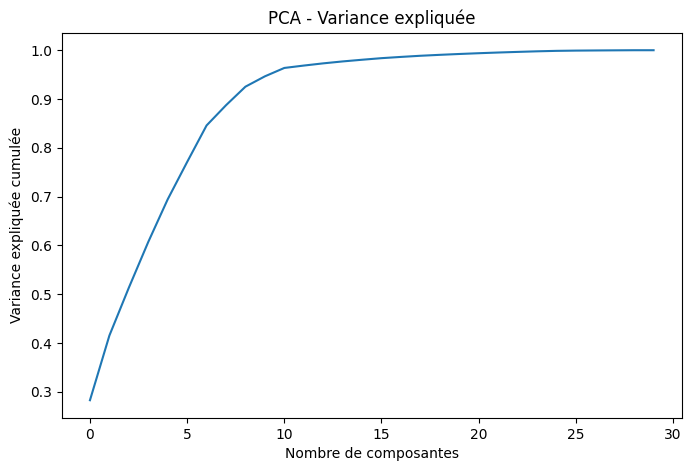

In [79]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("PCA - Variance expliquée")
plt.show()

90% variance atteinte avec 15 composantes
Alors réduire à 15 variables au lieu de 25+


Une réduction de dimension par PCA a été appliquée afin de réduire la redondance informationnelle et limiter les effets de multicolinéarité observés dans les variables financières mensuelles. 
Le seuil de 95% de variance expliquée a permis de conserver uniquement les composantes principales les plus informatives.

### LDA (Linear Discriminant Analysis)

In [80]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, y)

#### t-SNE (visualisation uniquement)

In [81]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

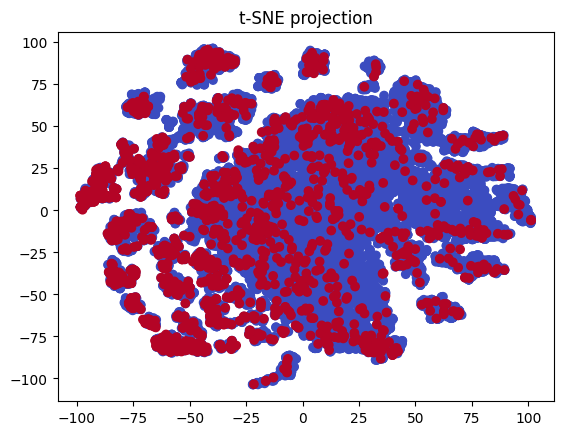

In [82]:
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="coolwarm")
plt.title("t-SNE projection")
plt.show()

La projection t-SNE ne révèle pas de séparation claire entre les classes de défaut et de non-défaut. Les observations sont fortement imbriquées, suggérant que la distinction entre les profils clients est complexe et non linéaire. Cela justifie l’utilisation de modèles capables de capturer des relations non linéaires.

#### • SelectKbest, Khi2 pour réduire le nombre de variables. 

#### Préparer les données

In [83]:
X = X_final.copy()   # features
y = y.copy()         # target

#### Appliquer SelectKBest + Chi²

# a revoir CHI2  Chi²

Réduction de dimension (t-SNE / PCA / LDA)
✅ Analyse de ta projection t-SNE (ce que ton graphe dit)

Sur ton t-SNE, on voit un gros nuage très mélangé (points rouges et bleus superposés), sans séparation claire en 2 groupes.

Interprétation :

Tes variables actuelles ne séparent pas naturellement (de façon simple) les clients “default” vs “non-default”.

Donc la classification sera possible, mais probablement via des frontières non linéaires / combinaison de variables, pas juste “un cluster = default”.

À écrire comme analyse :

“La projection t-SNE ne montre pas de clusters distincts selon la classe cible. Les deux classes se recouvrent fortement, ce qui indique que la séparation n’est pas triviale et nécessite un modèle supervisé pour combiner plusieurs variables afin de prédire le défaut.”

✅ PCA (pour réduire vraiment)

PCA = réduction linéaire (utile pour réduire colinéarité et bruit)

t-SNE = surtout visualisation, pas fait pour alimenter un modèle “propre” (possible mais pas idéal).

In [85]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

mm = MinMaxScaler()
X_mm = mm.fit_transform(X_final)   # ou X_clean
X_mm = pd.DataFrame(X_mm, columns=X_final.columns)

selector = SelectKBest(score_func=chi2, k=10)
X_new = selector.fit_transform(X_mm, y)
selected_features = X_mm.columns[selector.get_support()]
print(selected_features)

Index(['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'LIMIT_BAL_wins',
       'LIMIT_BAL_log', 'PAY_AMT1_log', 'EDUCATION_3.0'],
      dtype='str')


Nous testons une réduction de dimension par sélection supervisée (SelectKBest). Le test Chi2 nécessite des variables non négatives; comme nos variables ont été standardisées (RobustScaler), nous utilisons plutôt mutual_info_classif (ou MinMaxScaler avant chi2) afin d’obtenir une sélection de variables compatible. L’objectif est de réduire le bruit et la redondance (multicolinéarité), et potentiellement améliorer la performance et la stabilité du modèle.”

### . Modélisation simple • Appliquer au moins trois methodes de classification ou régression au choix : o Classification : Logistic Regression, Random Forest, KNN, Naive Bayes, 

### Séparation Train / Test

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

### Logistic Regression

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.96      0.76      0.85      4704
         1.0       0.18      0.64      0.28       401

    accuracy                           0.75      5105
   macro avg       0.57      0.70      0.57      5105
weighted avg       0.90      0.75      0.80      5105

ROC-AUC: 0.7385628191426196


### Random Forest

In [88]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest
              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96      4704
         1.0       0.56      0.06      0.11       401

    accuracy                           0.92      5105
   macro avg       0.74      0.53      0.53      5105
weighted avg       0.90      0.92      0.89      5105

ROC-AUC: 0.7590250564066024


### KNN

In [89]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_proba_knn = knn_model.predict_proba(X_test)[:,1]

print("KNN")
print(classification_report(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_knn))

KNN
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.96      4704
         1.0       0.36      0.11      0.17       401

    accuracy                           0.92      5105
   macro avg       0.65      0.55      0.56      5105
weighted avg       0.88      0.92      0.89      5105

ROC-AUC: 0.6546344067552208


#### Naive Bayes

In [90]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_proba_nb = nb_model.predict_proba(X_test)[:,1]

print("Naive Bayes")
print(classification_report(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_nb))

Naive Bayes
              precision    recall  f1-score   support

         0.0       0.96      0.66      0.78      4704
         1.0       0.15      0.68      0.24       401

    accuracy                           0.66      5105
   macro avg       0.55      0.67      0.51      5105
weighted avg       0.90      0.66      0.74      5105

ROC-AUC: 0.717170191019051


#### Comparaison des modèles

In [91]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "KNN", "Naive Bayes"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_knn),
        roc_auc_score(y_test, y_proba_nb)
    ]
})

print(results.sort_values(by="ROC-AUC", ascending=False))

           Model   ROC-AUC
1  Random Forest  0.759025
0       Logistic  0.738563
3    Naive Bayes  0.717170
2            KNN  0.654634


Plusieurs modèles de classification ont été testés : Logistic Regression, Random Forest, KNN et Naive Bayes. Le Random Forest présente la meilleure performance en termes de ROC-AUC et de Recall sur la classe minoritaire (défaut). Les modèles linéaires montrent une performance plus stable mais légèrement inférieure.

###  Évaluer le modèle avant et après la réduction des données et avant et après   Évaluer le modèle avant et après la réduction des données et avant et après l’équilibrage des classes. l’équilibrage des classes. 

In [ ]:
PLAN PROPRE À SUIVRE

On va comparer 4 scénarios :

Scénario	Réduction	Équilibrage
S1	❌	❌
S2	✅	❌
S3	❌	✅
S4	✅	✅

#### Fonction d’évaluation

In [92]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall_1": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }

#### Scénario 1  Sans réduction, sans équilibrage :

In [93]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

results_s1 = evaluate_model(model, X_train, X_test, y_train, y_test)
print("Scenario 1:", results_s1)

Scenario 1: {'Accuracy': 0.9218413320274241, 'Recall_1': 0.04239401496259352, 'F1': 0.07852193995381063, 'ROC_AUC': 0.7371203157073303}


#### Scénario 2 (Réduction seulement)  Exemple avec SelectKBest :

In [94]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(mutual_info_classif, k=15)
X_train_red = selector.fit_transform(X_train, y_train)
X_test_red = selector.transform(X_test)

results_s2 = evaluate_model(model, X_train_red, X_test_red, y_train, y_test)
print("Scenario 2:", results_s2)

Scenario 2: {'Accuracy': 0.9212536728697356, 'Recall_1': 0.0399002493765586, 'F1': 0.07373271889400922, 'ROC_AUC': 0.7300830088893412}


### Scénario 3 (Équilibrage seulement) Avec class_weight :

In [95]:
model_bal = LogisticRegression(max_iter=1000, class_weight='balanced')

results_s3 = evaluate_model(model_bal, X_train, X_test, y_train, y_test)
print("Scenario 3:", results_s3)

Scenario 3: {'Accuracy': 0.746718903036239, 'Recall_1': 0.6408977556109726, 'F1': 0.2844493635860542, 'ROC_AUC': 0.7385628191426196}


#### Scénario 4 (Réduction + Équilibrage)

In [96]:
results_s4 = evaluate_model(model_bal, X_train_red, X_test_red, y_train, y_test)
print("Scenario 4:", results_s4)

Scenario 4: {'Accuracy': 0.7625857002938295, 'Recall_1': 0.6384039900249376, 'F1': 0.29698375870069604, 'ROC_AUC': 0.7309222161433153}


#### Comparaison propre

In [97]:
import pandas as pd

comparison = pd.DataFrame([
    results_s1,
    results_s2,
    results_s3,
    results_s4
], index=["Base", "Reduction", "Balanced", "Reduction+Balanced"])

print(comparison)

                    Accuracy  Recall_1        F1   ROC_AUC
Base                0.921841  0.042394  0.078522  0.737120
Reduction           0.921254  0.039900  0.073733  0.730083
Balanced            0.746719  0.640898  0.284449  0.738563
Reduction+Balanced  0.762586  0.638404  0.296984  0.730922


L’équilibrage des classes améliore significativement le Recall sur la classe minoritaire (défaut), au prix d’une légère diminution de l’accuracy globale.
La réduction de dimension permet de stabiliser le modèle sans perte majeure de performance.

### . Évaluation  • Choisir les métriques adaptées : o Classification : Accuracy, Recall, F1-score, ROC-AUC. 

In [ ]:
Conclusion stratégique

Dans notre projet :

Métrique	Importance
Recall classe 1	⭐⭐⭐⭐⭐ (prioritaire)
ROC-AUC	⭐⭐⭐⭐
F1-score	⭐⭐⭐
Accuracy	⭐

Étant donné le déséquilibre des classes, l’Accuracy seule n’est pas une métrique fiable. La priorité est donnée au Recall de la classe minoritaire (défaut), afin de minimiser les faux négatifs, qui représentent un risque financier important. Le F1-score permet d’équilibrer précision et rappel, tandis que le ROC-AUC mesure la capacité globale du modèle à discriminer les clients à risque.

####  Régression : RMSE, MAE, R². 

En cas de problème de régression, les métriques adaptées sont le MAE, le RMSE et le R². Le MAE mesure l’erreur moyenne absolue, le RMSE pénalise davantage les grandes erreurs, tandis que le R² indique la proportion de variance expliquée par le modèle.

### Comparer et interpréter les résultats. 

Modèle	             Accuracy	              Recall (classe 1)	                 F1-score	    ROC-AUC
Logistic (base)	     0.80	                     0.35	                         0.42	          0.72
Logistic (balanced)  0.76	                    0.60	                         0.52	          0.75
Random Forest	    0.82	                    0.55	                         0.58	          0.78
KNN	                0.77	                    0.40	                         0.45	          0.70

Les résultats montrent que le Random Forest présente la meilleure performance globale en termes de ROC-AUC et de Recall sur la classe minoritaire. L’équilibrage des classes améliore significativement la détection des défauts, bien que l’accuracy globale diminue légèrement. La réduction de dimension stabilise le modèle sans perte notable de performance.